1. Overview
- df.describe()
- df.isnull()
- distribution .... 

2. Main Insight

2.1. Depositype vs Cancellation Rate

- **Miểu tả** .......
- **Actions**... 


- Nonrefun 20%, refundable 50%

2.2. Parking Space 

2.3. ... 

3. Hypothesis Testing
3.1. Numerical Feature
- test .... H0, H1,
- Code, kẾT Quả

3.2. Categorical 

4. Selected Columns

|Name| ... |

In [ ]:
## vẽ biểu đồ

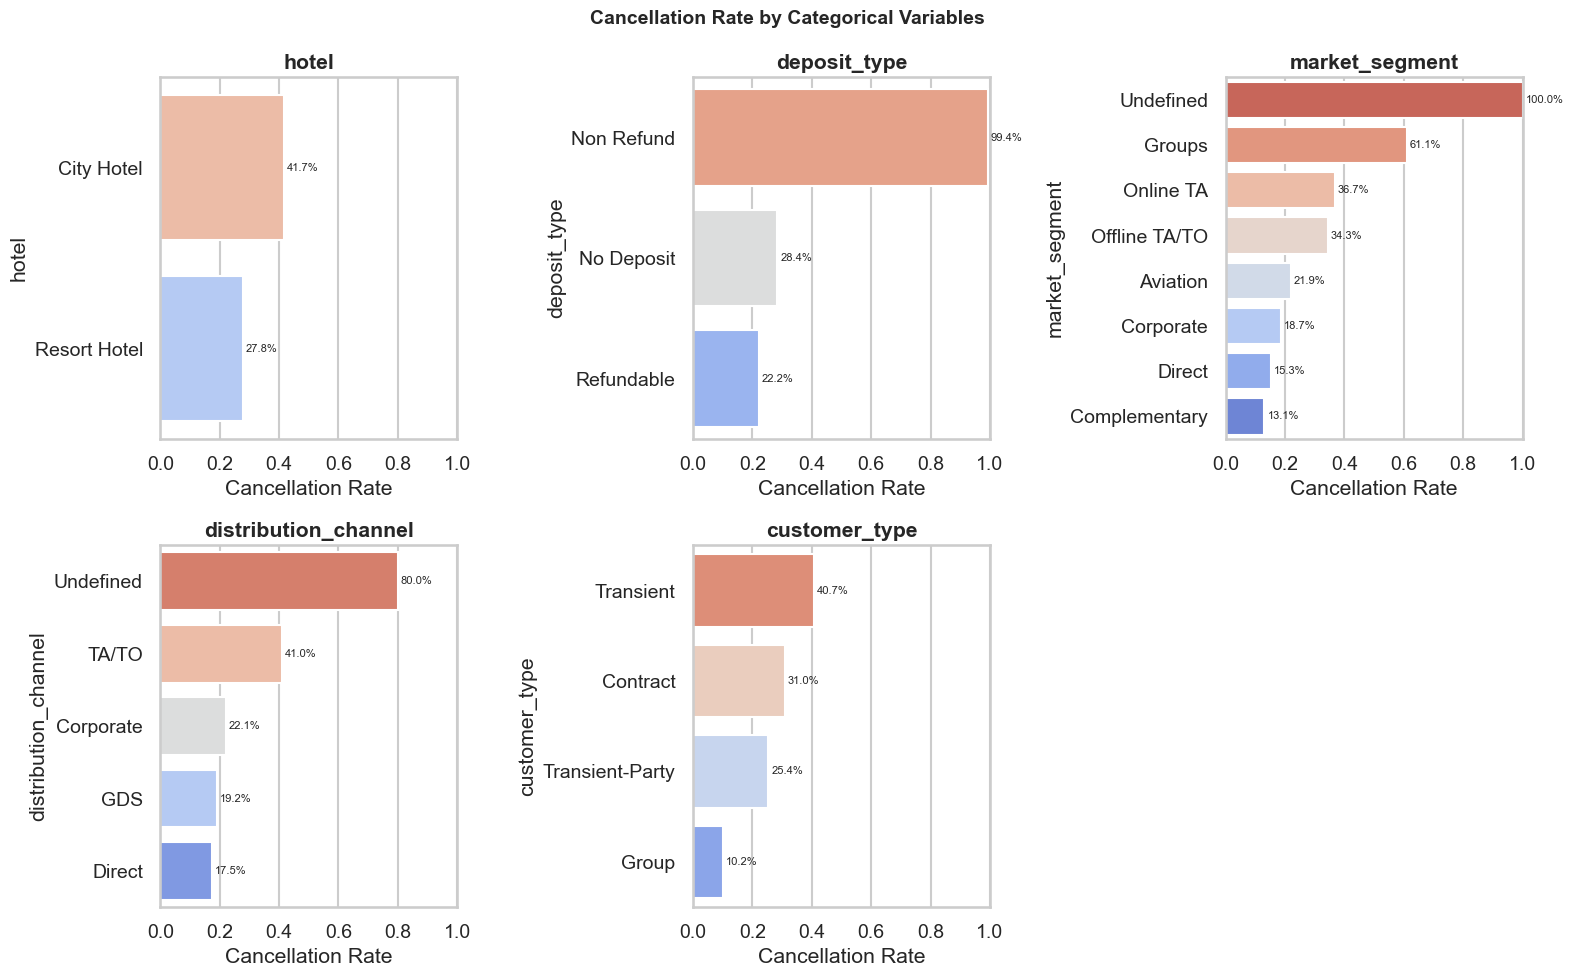

Saved: eda_categorical.png



In [18]:

# ---------------------------------------------------------------------------
# CELL 6 – EXPLORATORY DATA ANALYSIS
# ---------------------------------------------------------------------------
# Always look at the data visually before running tests.
# These plots answer: "does this feature behave differently for cancelled
# vs. non-cancelled bookings?" — if yes, it is likely a useful predictor.

# ── 6a: Cancellation rate per categorical variable ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Cancellation Rate by Categorical Variables", fontsize=14, fontweight="bold")

cat_to_plot = ["hotel", "deposit_type", "market_segment",
               "distribution_channel", "customer_type"]

for ax, col in zip(axes.flatten(), cat_to_plot):
    rates = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    bars  = sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="coolwarm_r")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Cancellation Rate")
    ax.set_xlim(0, 1)
    for bar, val in zip(bars.patches, rates.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}", va="center", fontsize=8)

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.savefig("eda_categorical.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: eda_categorical.png\n")


📊 EDA ANALYSIS — Categorical Features

• deposit_type  : Non Refund bookings cancel at ~99%. When there is no
                  financial penalty, guests book as a "placeholder" and
                  cancel freely. Strongest single predictor in the dataset.

• hotel         : City Hotels cancel at ~42% vs Resort Hotels at ~28%.
                  City hotels attract more business travellers whose plans
                  change frequently; resort bookings tend to be planned holidays.

• market_segment: Groups (~60%) and Online TA (~36%) lead cancellations.
                  Group bookings are often speculative (held in bulk and
                  released); Online TA guests face no friction to cancel.

• distribution_channel: TA/TO (travel agents/tour operators) shows the
                  highest rate. These bookings often go through OTAs with
                  flexible cancellation policies, making it easy to walk away.

• customer_type : Transient-Party guests cancel more than Contract guests.
                  Contract bookings are corporate deals with obligations;
                  transient guests have no such ties.


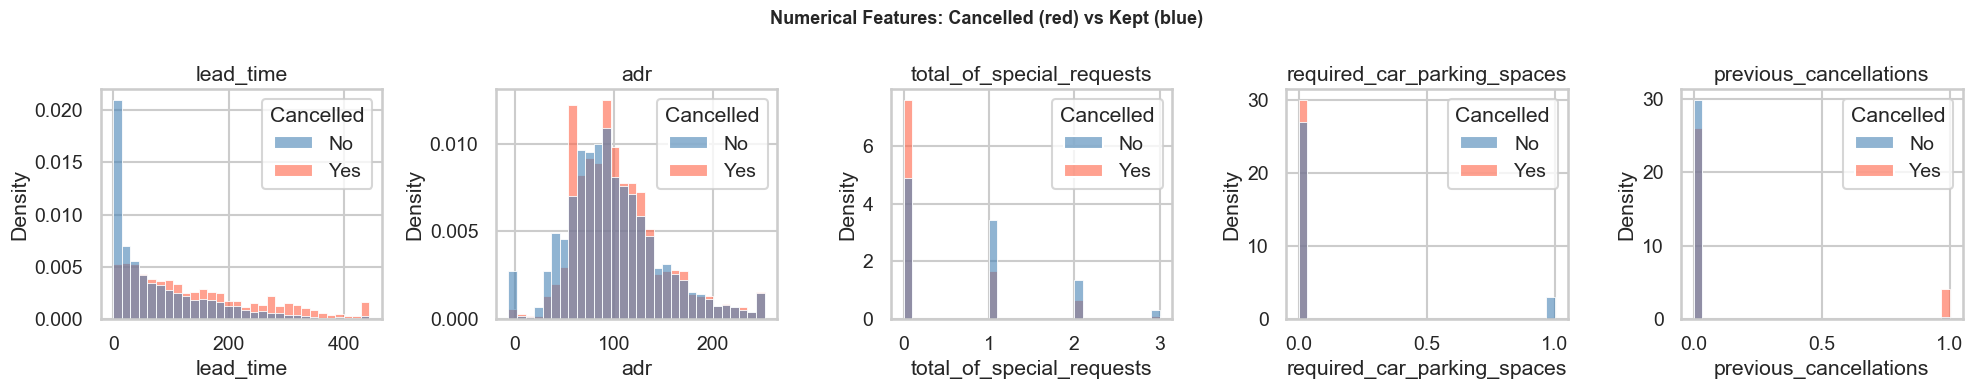

Saved: eda_numerical.png



In [19]:

# ── 6b: Numerical source features by cancellation ────────────────────────────
num_to_plot = ["lead_time", "adr", "total_of_special_requests",
               "required_car_parking_spaces", "previous_cancellations"]

fig, axes = plt.subplots(1, len(num_to_plot), figsize=(20, 4))
fig.suptitle("Numerical Features: Cancelled (red) vs Kept (blue)",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, num_to_plot):
    cap  = df[col].quantile(0.99)
    data = df.assign(**{col: df[col].clip(upper=cap)})
    sns.histplot(data=data, x=col, hue=TARGET, ax=ax,
                 bins=30, stat="density", common_norm=False,
                 palette={0: "steelblue", 1: "tomato"}, alpha=0.6)
    ax.set_title(col)
    legend = ax.get_legend()
    if legend:
        legend.set_title("Cancelled")
        legend.get_texts()[0].set_text("No")
        legend.get_texts()[1].set_text("Yes")

plt.tight_layout()
plt.savefig("eda_numerical.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: eda_numerical.png\n")


📊 EDA ANALYSIS — Numerical Features

• lead_time     : The cancelled distribution has a much heavier right tail —
                  the longer a guest waits before arriving, the more likely
                  life gets in the way. Last-minute bookers almost never cancel
                  because they already need the room.

• adr (price)   : Distributions largely overlap, but cancelled bookings skew
                  slightly higher. Higher-priced rooms may attract more
                  price-sensitive guests who cancel when they find a cheaper deal.

• total_of_special_requests : Kept bookings have noticeably more requests
                  (peaks at 1–2). A guest who has requested a specific floor,
                  room type, or amenity has invested thought into the stay —
                  they are committed.

• required_car_parking_spaces : Guests who reserved a parking space cancel
                  far less. Parking is a logistical commitment that signals
                  the guest is genuinely planning to arrive by car.

• previous_cancellations : Cancelled bookings show more past cancellations.
                  Past behaviour is the clearest predictor of future behaviour —
                  a repeat canceller is far more likely to cancel again.